# Assigntment 4

### Author: Zachary Fletcher

### Creation Date: sept 16 2025


# Task 1: Set up, Data import, and Preparation

In [26]:
#1.a
import pandas as pd
import numpy as np

import os

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import GaussianNB
from sklearn import tree

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics
from sklearn.model_selection import cross_validate

In [2]:
#1.a
bank_client_df = pd.read_csv('https://raw.githubusercontent.com/matthewpecsok/4482_fall_2024/main/data/CD_additional_modified.csv')
bank_client_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4112,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no
4113,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no
4114,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no
4115,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


In [3]:
#1.b
bank_client_df = bank_client_df.drop(columns= ['nr_employed', 'euribor3m', 'cons_conf_idx', 'cons_price_idx', 'emp_var_rate', 'previous', 'pdays', 'campaign', 'duration', 'age'], axis = 1)
bank_client_df

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,nonexistent,no
1,services,single,high.school,no,no,no,telephone,may,fri,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,jun,wed,nonexistent,no
3,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,nonexistent,no
4,admin.,married,university.degree,no,yes,no,cellular,nov,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
4112,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,nonexistent,no
4113,admin.,married,high.school,no,yes,no,telephone,jul,fri,nonexistent,no
4114,student,single,high.school,no,no,no,cellular,may,mon,failure,no
4115,admin.,married,high.school,no,no,no,cellular,aug,fri,nonexistent,no


In [4]:
#1.c
y_target = bank_client_df.pop('y')
y_target = y_target.eq('yes').mul(1)

In [5]:
bank_client_df

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,nonexistent
1,services,single,high.school,no,no,no,telephone,may,fri,nonexistent
2,services,married,high.school,no,yes,no,telephone,jun,wed,nonexistent
3,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,nonexistent
4,admin.,married,university.degree,no,yes,no,cellular,nov,mon,nonexistent
...,...,...,...,...,...,...,...,...,...,...
4112,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,nonexistent
4113,admin.,married,high.school,no,yes,no,telephone,jul,fri,nonexistent
4114,student,single,high.school,no,no,no,cellular,may,mon,failure
4115,admin.,married,high.school,no,no,no,cellular,aug,fri,nonexistent


In [6]:
y_target

,y
0,0
1,0
2,0
3,0
4,0
...,...
4112,0
4113,0
4114,0
4115,0


In [7]:
#1.d
bank_client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4117 entries, 0 to 4116
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   job          4117 non-null   object
 1   marital      4117 non-null   object
 2   education    4117 non-null   object
 3   default      4117 non-null   object
 4   housing      4117 non-null   object
 5   loan         4117 non-null   object
 6   contact      4117 non-null   object
 7   month        4117 non-null   object
 8   day_of_week  4117 non-null   object
 9   poutcome     4117 non-null   object
dtypes: object(10)
memory usage: 321.8+ KB


In [8]:
#1.d
bank_client_df.describe()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,4117,4117,4117,4117,4117,4117,4117,4117,4117,4117
unique,12,4,7,2,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,1012,2508,1264,3314,2175,3347,2650,1378,860,3522


In [9]:
#1.d
bank_client_df.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,nonexistent
1,services,single,high.school,no,no,no,telephone,may,fri,nonexistent
2,services,married,high.school,no,yes,no,telephone,jun,wed,nonexistent
3,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,nonexistent
4,admin.,married,university.degree,no,yes,no,cellular,nov,mon,nonexistent


In [11]:
# 1.e
bank_client_df_enc = pd.get_dummies(bank_client_df)
bank_client_df_enc

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4112,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4113,True,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4114,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
4115,True,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [16]:
#1.f
x_train, x_test, y_train, y_test = train_test_split(bank_client_df_enc, y_target, test_size=0.3, random_state=0, stratify=y_target)

In [23]:
#1.h
y_train.value_counts()/len(y_train)

,count
y,
0,0.890316
1,0.109684


In [24]:
#1.h
y_test.value_counts()/len(y_test)

,count
y,
0,0.890777
1,0.109223


In [25]:
#1.h
y_target.value_counts()/len(y_target)

,count
y,
0,0.890454
1,0.109546


# Task 2: Simple Decision Tree Training and Testing

In [46]:
random_state = 42
tree_model1 = tree.DecisionTreeClassifier(random_state=random_state, min_samples_split=2500)
tree_model1

DecisionTreeClassifier(min_samples_split=2500, random_state=42)

In [47]:
tree_model1.fit(x_train, y_train)

DecisionTreeClassifier(min_samples_split=2500, random_state=42)

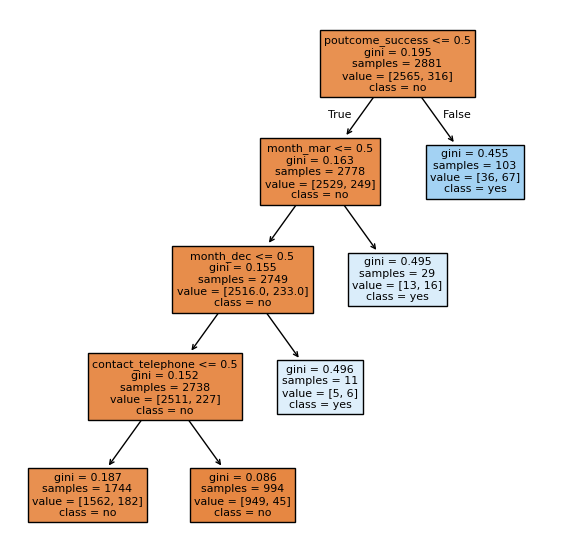

In [50]:
fig1 = plt.figure(figsize=(7,7))
Tree_fig1 = tree.plot_tree(tree_model1, feature_names=x_train.columns, class_names=['no', 'yes'], filled=True)
plt.show()

In [51]:
# confusion matrix for training set
y_train_pred_tree = tree_model1.predict(x_train)
cm_train_tree = confusion_matrix(y_train, y_train_pred_tree)
cm_train_tree

array([[2511,   54],
       [ 227,   89]])

In [52]:
#Evaluate performance
print(metrics.classification_report(y_train, y_train_pred_tree))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      2565
           1       0.62      0.28      0.39       316

    accuracy                           0.90      2881
   macro avg       0.77      0.63      0.67      2881
weighted avg       0.88      0.90      0.89      2881



In [53]:
# confusion matrix for test set
y_test_pred_tree = tree_model1.predict(x_test)
cm_test_tree = confusion_matrix(y_test, y_test_pred_tree)
cm_test_tree

array([[1077,   24],
       [ 104,   31]])

In [55]:
#Evaluate performance
print(metrics.classification_report(y_test, y_test_pred_tree))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1101
           1       0.56      0.23      0.33       135

    accuracy                           0.90      1236
   macro avg       0.74      0.60      0.64      1236
weighted avg       0.87      0.90      0.88      1236



#Task 3 - Simple Naïve Bayes Model Training and Testing

In [57]:
cnb = CategoricalNB()
cnb.fit(x_train, y_train)

CategoricalNB()

In [58]:
# Confusion Matrix for training set
y_train_pred_cnb = cnb.predict(x_train)
cm_train_cnb = confusion_matrix(y_train, y_train_pred_cnb)
cm_train_cnb

array([[2432,  133],
       [ 199,  117]])

In [59]:
#Evaluate performance
print(metrics.classification_report(y_train, y_train_pred_cnb))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2565
           1       0.47      0.37      0.41       316

    accuracy                           0.88      2881
   macro avg       0.70      0.66      0.67      2881
weighted avg       0.87      0.88      0.88      2881



In [60]:
# confusion matrix for test set
y_test_pred_cnb = cnb.predict(x_test)
cm_test_cnb = confusion_matrix(y_test, y_test_pred_cnb)
cm_test_cnb

array([[1051,   50],
       [  90,   45]])

In [61]:
#Evaluate performance
print(metrics.classification_report(y_test, y_test_pred_cnb))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1101
           1       0.47      0.33      0.39       135

    accuracy                           0.89      1236
   macro avg       0.70      0.64      0.66      1236
weighted avg       0.87      0.89      0.88      1236



# Task 4 - 5-fold cross-validate the decision tree and naive Bayes evaluation performance

In [63]:
cv_scores_tree = cross_validate(tree_model1, bank_client_df_enc, y_target, cv=5, scoring=('accuracy', 'precision', 'recall', 'f1'), return_train_score=True)
pd.DataFrame(cv_scores_tree)

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.014677,0.028037,0.911408,0.898269,0.742857,0.604839,0.288889,0.207756,0.416000,0.309278
1,0.014879,0.045763,0.890777,0.903432,0.518519,0.659091,0.153846,0.241667,0.237288,0.353659
2,0.011276,0.016620,0.901580,0.900121,0.628571,0.609589,0.244444,0.246537,0.352000,0.351085
3,0.018059,0.017636,0.894289,0.902247,0.536585,0.624204,0.244444,0.271468,0.335878,0.378378
4,0.014551,0.019978,0.897934,0.901336,0.600000,0.660714,0.200000,0.204986,0.300000,0.312896


In [64]:
cv_scores_cnb = cross_validate(cnb, bank_client_df_enc, y_target, cv=5, scoring=('accuracy', 'precision', 'recall', 'f1'), return_train_score=True)
pd.DataFrame(cv_scores_cnb)

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.013064,0.011493,0.883495,0.878834,0.460526,0.435374,0.388889,0.354571,0.421687,0.390840
1,0.017677,0.019479,0.879854,0.880960,0.439394,0.446667,0.318681,0.372222,0.369427,0.406061
2,0.010469,0.010878,0.880923,0.879174,0.445946,0.439739,0.366667,0.373961,0.402439,0.404192
3,0.010385,0.011010,0.886999,0.884639,0.474576,0.466667,0.311111,0.368421,0.375839,0.411765
4,0.010278,0.011356,0.874848,0.882514,0.423529,0.454545,0.400000,0.360111,0.411429,0.401855


In [65]:
!jupyter nbconvert --to html '/content/A4_Fletcher_Zachary (5).ipynb'

[NbConvertApp] Converting notebook /content/A4_Fletcher_Zachary (5).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 510398 bytes to /content/A4_Fletcher_Zachary (5).html
